In [19]:
%load_ext autoreload
%autoreload 2
import numpy as np
import matplotlib.pyplot as plt
from coffea import util
from coffea.processor import accumulate
import os
import re
import pandas as pd
import hist
import matplotlib as mpl
import mplhep
import sys
import hist
import hist.intervals


sys.path.append("/uscms/home/reshmar/nobackup/IDMe_Run3_Collab/CMSSW_13_0_13/src/iDMe/python_analysis/analysisTools")
import plotTools as ptools
import utils

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [20]:
f_sig = "/uscms/home/reshmar/nobackup/IDMe_Run3_Collab/CMSSW_13_0_13/src/iDMe/python_analysis/coffea/AllInOne_2022/Big_pT_Resolution_dask.coffea"
# f_sig = "/uscms/home/reshmar/nobackup/IDMe_Run3_Collab/CMSSW_13_0_13/src/iDMe/python_analysis/coffea/BigSamples_2022/Futures_Resolution.coffea"

sig_histo = util.load(f_sig) [0]
# sig_histo

sig_2022_Mchi-11p0_dMchi-2p0_ctau-100
Hist(
  Variable([0, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 22, 30], name='Gen_pt_res'),
  Regular(700, -0.5, 0.5, name='Res_LPT'),
  storage=Weight()) # Sum: WeightedSum(value=2488, variance=2488) (WeightedSum(value=2506, variance=2506) with flow)
sig_2022_Mchi-22p0_dMchi-4p0_ctau-100
sig_2022_Mchi-33p0_dMchi-6p0_ctau-100
sig_2022_Mchi-44p0_dMchi-8p0_ctau-100
sig_2022_Mchi-55p0_dMchi-10p0_ctau-100
sig_2022_Mchi-63p0_dMchi-6p0_ctau-100
sig_2022_Mchi-66p0_dMchi-12p0_ctau-100
sig_2022_Mchi-73p5_dMchi-7p0_ctau-100
sig_2022_Mchi-77p0_dMchi-14p0_ctau-100
sig_2022_Mchi-84p0_dMchi-8p0_ctau-100
sig_2022_Mchi-88p0_dMchi-16p0_ctau-100
sig_2022_Mchi-94p5_dMchi-9p0_ctau-100
sig_2022_Mchi-99p0_dMchi-18p0_ctau-100
sig_2022_Mchi-105p0_dMchi-10p0_ctau-100
sig_2022_Mchi-110p0_dMchi-20p0_ctau-100


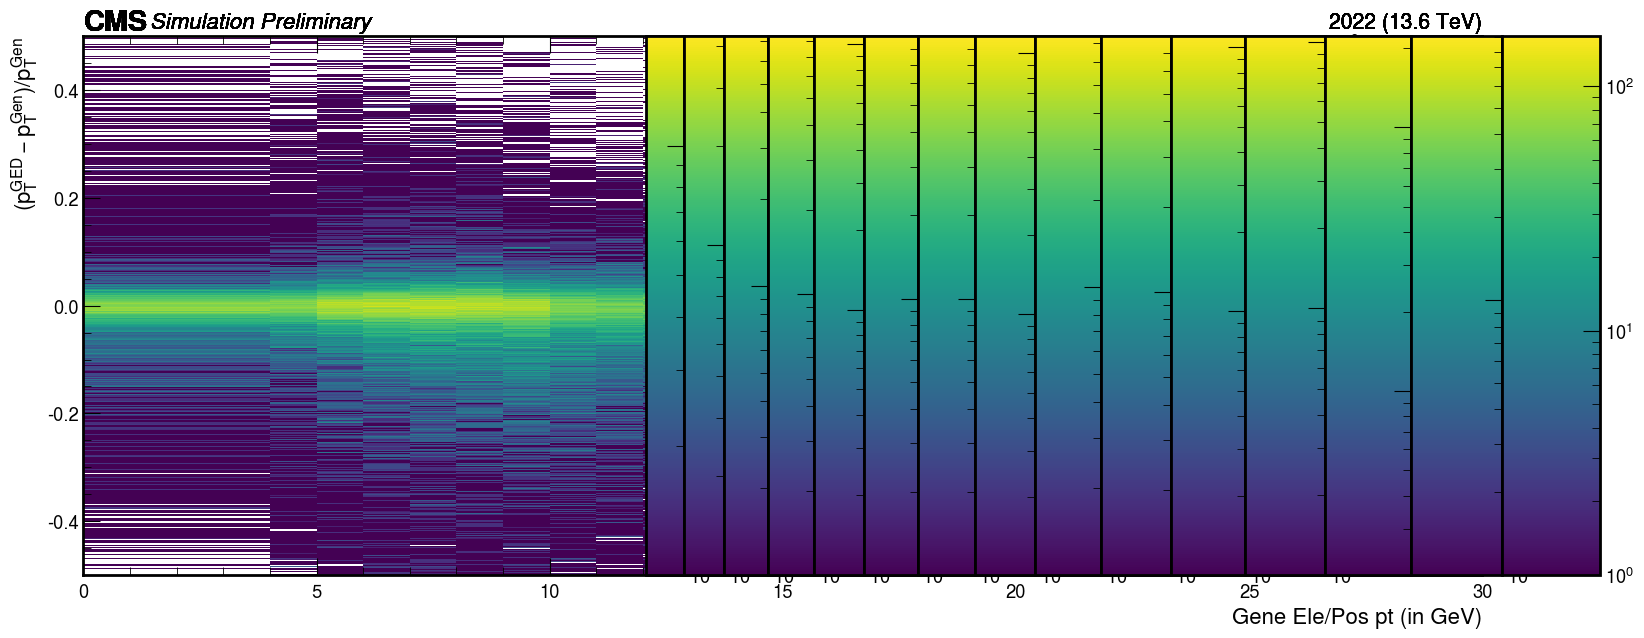

In [21]:
fig, ax = plt.subplots(figsize=(7,7))


# Plot settings
plot_dict = {
    'variable':'res_LPT_gen_ptbin',
    'cut': 'cut1',
    'year': 2022
}


style_2d_dict = {
    'fig': fig,
    'ax': ax,
    'xrebin': None,
    'yrebin': None,
    'xlim': None,     # if None, the default will show up; otherwise give as a list, i.e. [0, 10]  
    'ylim': None,     # if None, the default will show up; otherwise give as a list, i.e. [0, 10]
    'doLogy': False, 
    'doLogx': False,
    'doLogz': True,
    'xlabel': "Gene Ele/Pos pt (in GeV)",   # if None, the default will show up; otherwise give as a string, i.e. 'Electron dxy'
    'ylabel': r'$(p_{T}^{\mathrm{GED}}-p_{T}^{\mathrm{Gen}})/p_{T}^{\mathrm{Gen}}$',   # if None, the default will show up; otherwise give as a string, i.e. 'Efficiency'
    'zlabel': None,   
    'flow': None,     # overflow
    'doSave': False,
    'outDir': './plots/signal_2018',
    'outName': f'ptvslxy.png'
}


samples = {
    10: 
    {
        
        0.2: [100],
    },
    20: 
    {
        
        0.2: [100],
        
    },
    30: 
    {
       
        0.2: [100]
    },
    40: 
    {
        0.2: [100],
    },
    50:
    {
        
        0.2: [100],
    },
    60:
    {
        
         0.1: [100],
         0.2: [100]
    
    },
    70:
    {    0.1: [100],
         0.2: [100],
    },
    80:
    {    0.1: [100],
         0.2: [100],
    },
    90:
    {    0.1: [100],
         0.2: [100],
    },
    100:
    {    0.1: [100],
         0.2: [100],
    }
 
}

h_list_lpt=[]
h_sum_lpt = None

for m1,deltas in samples.items():
    for delta, ctaus in deltas.items():
        for ctau in ctaus:
            h_lpt = ptools.plot_signal_2D(sig_histo, m1, delta, ctau, plot_dict, style_2d_dict)
            h_list_lpt.append(h_lpt)            
            if h_sum_lpt is None:
                h_sum_lpt = h_lpt.copy()
                print (h_sum_lpt)
            else:
                h_sum_lpt += h_lpt



# Per-pT-bin DSCB fit-range tuning

This notebook keeps the **same pT-resolution histogram, residual bin width, DSCB model, parameter ordering, initial guesses, bounds, and `curve_fit` prescription** as the original pT-binned notebook. The only fit ingredient tuned here is the **fit range**.

The baseline for every generated-pT bin is the original range `(-0.30, 0.30)`. Candidate ranges are tested independently for each pT bin. A candidate is allowed to replace the baseline only when the fitted **core sigma remains stable** relative to that bin's baseline sigma. This follows the idea used in `Pt_resolution_GED_tuning.ipynb`: improve fit quality without obtaining an artificially different resolution just by cutting away difficult parts of the distribution.

The workflow is:

1. Reproduce the original 0.01 residual binning and baseline `[-0.30, 0.30]` fits.
2. Scan several symmetric and mildly asymmetric fit ranges for **every pT bin**.
3. Reject candidates whose fitted sigma changes by more than the allowed tolerance.
4. Among the sigma-stable candidates, select the range with the lowest chi2/ndof. If nothing safer improves the baseline, the original range remains selected.
5. Compare baseline and selected fits visually and print a compact final table.
6. Use the selected per-bin fits to make the final sigma-vs-generated-pT resolution plot.

**Important:** histogram rebinning is intentionally *not* tuned here. That keeps this study focused on the fit-range question only.

In [22]:
# ============================================================
# SETTINGS: keep the original histogram binning; tune fit range only
# ============================================================

# Same residual-bin width used in the original notebook.
RES_BIN_WIDTH = 0.01

# Baseline/original fit range.
ORIGINAL_FIT_RANGE = (-0.30, 0.30)

# Display range only. This does NOT affect curve_fit.
plot_min = -0.50
plot_max =  0.50

# Protect the DSCB core width.
# A candidate range is considered safe only if sigma changes by <=10%
# relative to the ORIGINAL-RANGE sigma for the same pT bin.
MAX_SIGMA_REL_CHANGE = 0.10

# Require at least this many populated points beyond the 7 DSCB parameters.
# This helps avoid choosing an extremely narrow range just because its chi2 is small.
N_PARAMETERS = 7
MIN_NDOF = 8

# Candidate fit ranges. All pT bins scan the same menu, but each bin chooses
# independently, so the final ranges can be different from bin to bin.
# The original range is always included.
FIT_RANGE_CANDIDATES = [
    (-0.30,  0.30),
    (-0.30,  0.25),
    (-0.25,  0.30),
    (-0.25,  0.25),
    (-0.25,  0.20),
    (-0.20,  0.25),
    (-0.20,  0.20),
    (-0.20,  0.15),
    (-0.15,  0.20),
    (-0.15,  0.15),
    (-0.15,  0.12),
    (-0.12,  0.15),
    (-0.12,  0.12),
]

# Optional manual overrides after you inspect the overlay plots.
# Example: MANUAL_RANGE_OVERRIDE = {14: (-0.15, 0.15)}
MANUAL_RANGE_OVERRIDE = {}

print(f'Baseline fit range       : {ORIGINAL_FIT_RANGE}')
print(f'Residual bin width       : {RES_BIN_WIDTH}')
print(f'Max allowed sigma change: {MAX_SIGMA_REL_CHANGE:.0%}')
print(f'Number of range choices  : {len(FIT_RANGE_CANDIDATES)}')

Baseline fit range       : (-0.3, 0.3)
Residual bin width       : 0.01
Max allowed sigma change: 10%
Number of range choices  : 13


In [23]:
# ============================================================
# Build the histogram used for all fits -- identical bin width for every pT bin
# ============================================================

original_edges = h_sum_lpt.axes[1].edges
original_widths = np.diff(original_edges)

if not np.allclose(original_widths, original_widths[0]):
    raise ValueError(
        'The stored residual axis has variable-width bins. '
        'This notebook assumes uniform stored bins.'
    )

stored_width = original_widths[0]
rebin_factor = int(round(RES_BIN_WIDTH / stored_width))

if rebin_factor < 1:
    raise ValueError(
        f'Requested residual width {RES_BIN_WIDTH:g} is finer than stored width {stored_width:g}.'
    )

actual_width = rebin_factor * stored_width
if not np.isclose(actual_width, RES_BIN_WIDTH):
    raise ValueError(
        f'Requested width {RES_BIN_WIDTH:g} is not an integer multiple of stored width {stored_width:g}.'
    )

h_fit = h_sum_lpt[:, hist.rebin(rebin_factor)]

print(f'Stored residual bin width : {stored_width:g}')
print(f'Rebin factor              : {rebin_factor}')
print(f'Residual bin width used   : {actual_width:g}')
print(f'Generated-pT bins         : {list(h_fit.axes[0].edges)}')

Stored residual bin width : 0.00142857
Rebin factor              : 7
Residual bin width used   : 0.01
Generated-pT bins         : [0.0, 4.0, 5.0, 6.0, 7.0, 8.0, 9.0, 10.0, 11.0, 12.0, 13.0, 14.0, 15.0, 16.0, 17.0, 22.0, 30.0]


In [24]:
# ============================================================
# DSCB MODEL -- unchanged from the original pT notebook
# ============================================================

def double_cb(x, u, sig, nl, a_l, nr, a_r, N):
    t = (x-u)/sig
    al = abs(a_l)
    ar = abs(a_r)

    left_tail = t < -al
    core = (t >= -al) & (t <= ar)
    right_tail = t > ar

    y = np.empty_like(t)
    y[core] = np.exp(-0.5*t[core]*t[core])

    A_L = (nl/al)**nl * np.exp(-0.5*al**2)
    B_L = (nl/al) - al
    y[left_tail] = A_L / (B_L - t[left_tail])**nl

    A_R = (nr/ar)**nr * np.exp(-0.5*ar**2)
    B_R = (nr/ar) - ar
    y[right_tail] = A_R / (B_R + t[right_tail])**nr

    return N*y

In [25]:
# ============================================================
# Extract one pT bin + fit it over one requested range
# ============================================================
from scipy.optimize import curve_fit


def make_bin_data(ptbin_index):
    """Return histogram values and uncertainties for one generated-pT bin."""
    pt_low = h_fit.axes[0].edges[ptbin_index]
    pt_high = h_fit.axes[0].edges[ptbin_index + 1]

    y = h_fit[ptbin_index, :].values()
    variances = h_fit[ptbin_index, :].variances()
    yerr = np.sqrt(variances)
    edges = h_fit.axes[1].edges
    x = 0.5 * (edges[:-1] + edges[1:])

    return {
        'ptbin_index': ptbin_index,
        'genpt_bin': (pt_low, pt_high),
        'xdata': x,
        'ydata': y,
        'yerror': yerr,
    }


def fit_one_bin(ptbin_index, fit_range):
    """
    Fit one generated-pT bin with the SAME DSCB prescription as the original notebook.
    Only fit_range is allowed to change.
    """
    data = make_bin_data(ptbin_index)
    x = data['xdata']
    y = data['ydata']
    sig_y = data['yerror']

    fit_min_i, fit_max_i = fit_range
    mask = (
        (y > 0) &
        (sig_y > 0) &
        np.isfinite(y) &
        np.isfinite(sig_y) &
        (x >= fit_min_i) &
        (x <= fit_max_i)
    )

    xfit = x[mask]
    yfit = y[mask]
    yerrfit = sig_y[mask]

    ndof = len(xfit) - N_PARAMETERS
    if ndof < MIN_NDOF:
        raise ValueError(
            f'pT bin {ptbin_index}: only {len(xfit)} populated fit points '
            f'in range {fit_range}, giving ndof={ndof}.'
        )

    # Same initial-guess prescription as the original notebook.
    mean0 = np.average(xfit, weights=yfit)
    sigma0 = np.sqrt(np.average((xfit-mean0)**2, weights=yfit))
    initial_guess = [mean0, sigma0, 1, 0.2, 1, 0.2, yfit.max()]

    # Same bounds prescription as the original notebook.
    lower = [xfit.min(), 1e-5, 0.5, 0.05, 0.1, 0.05, 0]
    upper = [xfit.max(), xfit.max()-xfit.min(), 2, 1, 5, 2, 5*yfit.max()]

    popt, pcov = curve_fit(
        double_cb,
        xfit,
        yfit,
        p0=initial_guess,
        sigma=yerrfit,
        absolute_sigma=True,
        bounds=(lower, upper),
        maxfev=20000,
    )

    perr = np.sqrt(np.diag(pcov))
    prediction = double_cb(xfit, *popt)
    chi2 = np.sum(((yfit-prediction)/yerrfit)**2)
    chi2ndof = chi2/ndof

    return {
        **data,
        'fit_range': fit_range,
        'xfit': xfit,
        'yfit': yfit,
        'yerrfit': yerrfit,
        'popt': popt,
        'perr': perr,
        'chi2': chi2,
        'ndof': ndof,
        'chi2/ndof': chi2ndof,
        'fit_mean': popt[0],
        'fit_mean_unc': perr[0],
        'fit_sigma': popt[1],
        'fit_sigma_unc': perr[1],
    }

## 1. Baseline fits

First reproduce the original `[-0.30, 0.30]` fit for every generated-pT bin. These values define the **reference sigma** for that pT bin. Candidate ranges are compared to this sigma, not to one global sigma.

In [26]:
baseline_results = {}
baseline_rows = []

n_pt_bins = len(h_fit.axes[0].edges) - 1

for idx in range(n_pt_bins):
    result = fit_one_bin(idx, ORIGINAL_FIT_RANGE)
    baseline_results[idx] = result

    baseline_rows.append({
        'pT bin index': idx,
        'gen pT range': result['genpt_bin'],
        'fit range': result['fit_range'],
        'sigma': result['fit_sigma'],
        'sigma unc': result['fit_sigma_unc'],
        'chi2/ndof': result['chi2/ndof'],
        'ndof': result['ndof'],
    })

baseline_df = pd.DataFrame(baseline_rows)
display(baseline_df)

,pT bin index,gen pT range,fit range,sigma,sigma unc,chi2/ndof,ndof
0,0,"(0.0, 4.0)","(-0.3, 0.3)",0.016996,0.000183,1.798380,53
1,1,"(4.0, 5.0)","(-0.3, 0.3)",0.018198,0.000273,1.542001,53
2,2,"(5.0, 6.0)","(-0.3, 0.3)",0.018138,0.000269,1.492207,53
3,3,"(6.0, 7.0)","(-0.3, 0.3)",0.019873,0.000289,1.649210,53
4,4,"(7.0, 8.0)","(-0.3, 0.3)",0.019495,0.000354,1.979081,53
5,5,"(8.0, 9.0)","(-0.3, 0.3)",0.020271,0.000366,1.786683,53
6,6,"(9.0, 10.0)","(-0.3, 0.3)",0.020405,0.000444,1.547545,53
7,7,"(10.0, 11.0)","(-0.3, 0.3)",0.021188,0.000709,1.847017,53
8,8,"(11.0, 12.0)","(-0.3, 0.3)",0.021859,0.000662,1.327240,53
9,9,"(12.0, 13.0)","(-0.3, 0.3)",0.022855,0.000691,1.532693,53


## 2. Scan fit ranges independently for every pT bin

For each pT bin, every candidate range is fit independently. A candidate is marked **sigma stable** when

\[
\frac{|\sigma_{\rm candidate}-\sigma_{\rm baseline}|}{\sigma_{\rm baseline}} \leq 10\%.
\]

A candidate must also successfully converge and retain enough degrees of freedom. Among the stable candidates, the notebook chooses the one with the lowest chi2/ndof. The original range is always available, so a bin can remain unchanged.

In [27]:
range_scan_rows = []
range_scan_fits = {idx: {} for idx in range(n_pt_bins)}
selected_fit_ranges = {}
selection_rows = []

for idx in range(n_pt_bins):
    baseline = baseline_results[idx]
    baseline_sigma = baseline['fit_sigma']
    baseline_chi2ndof = baseline['chi2/ndof']

    successful_stable_results = []

    for fit_range in FIT_RANGE_CANDIDATES:
        try:
            result = fit_one_bin(idx, fit_range)
            range_scan_fits[idx][fit_range] = result

            sigma_rel_change = abs(result['fit_sigma'] - baseline_sigma) / baseline_sigma
            sigma_stable = sigma_rel_change <= MAX_SIGMA_REL_CHANGE

            range_scan_rows.append({
                'pT bin index': idx,
                'gen pT range': result['genpt_bin'],
                'fit range': str(fit_range),
                'sigma': result['fit_sigma'],
                'sigma unc': result['fit_sigma_unc'],
                'sigma rel. change': sigma_rel_change,
                'chi2/ndof': result['chi2/ndof'],
                'ndof': result['ndof'],
                'sigma stable': sigma_stable,
                'fit success': True,
            })

            if sigma_stable:
                successful_stable_results.append(result)

        except Exception as exc:
            range_scan_rows.append({
                'pT bin index': idx,
                'gen pT range': baseline['genpt_bin'],
                'fit range': str(fit_range),
                'sigma': np.nan,
                'sigma unc': np.nan,
                'sigma rel. change': np.nan,
                'chi2/ndof': np.nan,
                'ndof': np.nan,
                'sigma stable': False,
                'fit success': False,
                'failure': str(exc),
            })

    # Baseline should always be in the stable set, but fall back explicitly for safety.
    if successful_stable_results:
        best = min(successful_stable_results, key=lambda r: r['chi2/ndof'])
    else:
        best = baseline

    selected_fit_ranges[idx] = best['fit_range']

    selection_rows.append({
        'pT bin index': idx,
        'gen pT range': baseline['genpt_bin'],
        'baseline range': ORIGINAL_FIT_RANGE,
        'selected range': best['fit_range'],
        'baseline sigma': baseline_sigma,
        'selected sigma': best['fit_sigma'],
        'sigma rel. change': abs(best['fit_sigma']-baseline_sigma)/baseline_sigma,
        'baseline chi2/ndof': baseline_chi2ndof,
        'selected chi2/ndof': best['chi2/ndof'],
        'chi2 improvement': baseline_chi2ndof - best['chi2/ndof'],
    })

range_scan_df = pd.DataFrame(range_scan_rows)
selection_df = pd.DataFrame(selection_rows)

print('All candidate fits:')
display(range_scan_df)

print('\nAutomatically selected range for each pT bin:')
display(selection_df)

All candidate fits:


,pT bin index,gen pT range,fit range,sigma,sigma unc,sigma rel. change,chi2/ndof,ndof,sigma stable,fit success
0,0,"(0.0, 4.0)","(-0.3, 0.3)",0.016996,0.000183,0.000000,1.798380,53,True,True
1,0,"(0.0, 4.0)","(-0.3, 0.25)",0.016990,0.000184,0.000352,1.961219,48,True,True
2,0,"(0.0, 4.0)","(-0.25, 0.3)",0.017020,0.000183,0.001395,1.760133,48,True,True
3,0,"(0.0, 4.0)","(-0.25, 0.25)",0.017016,0.000184,0.001158,1.937496,43,True,True
4,0,"(0.0, 4.0)","(-0.25, 0.2)",0.017023,0.000184,0.001537,2.109913,38,True,True
...,...,...,...,...,...,...,...,...,...,...
203,15,"(22.0, 30.0)","(-0.15, 0.2)",0.032493,0.000780,0.062964,1.469768,28,True,True
204,15,"(22.0, 30.0)","(-0.15, 0.15)",0.032455,0.000790,0.064061,1.455983,23,True,True
205,15,"(22.0, 30.0)","(-0.15, 0.12)",0.032124,0.000867,0.073604,1.568378,20,True,True
206,15,"(22.0, 30.0)","(-0.12, 0.15)",0.032655,0.000766,0.058283,1.448117,20,True,True



Automatically selected range for each pT bin:


,pT bin index,gen pT range,baseline range,selected range,baseline sigma,selected sigma,sigma rel. change,baseline chi2/ndof,selected chi2/ndof,chi2 improvement
0,0,"(0.0, 4.0)","(-0.3, 0.3)","(-0.25, 0.3)",0.016996,0.017020,0.001395,1.798380,1.760133,0.038247
1,1,"(4.0, 5.0)","(-0.3, 0.3)","(-0.3, 0.3)",0.018198,0.018198,0.000000,1.542001,1.542001,0.000000
2,2,"(5.0, 6.0)","(-0.3, 0.3)","(-0.12, 0.15)",0.018138,0.018113,0.001361,1.492207,1.368778,0.123429
3,3,"(6.0, 7.0)","(-0.3, 0.3)","(-0.2, 0.15)",0.019873,0.020031,0.007973,1.649210,1.370290,0.278920
4,4,"(7.0, 8.0)","(-0.3, 0.3)","(-0.25, 0.3)",0.019495,0.019762,0.013686,1.979081,1.457225,0.521856
5,5,"(8.0, 9.0)","(-0.3, 0.3)","(-0.2, 0.2)",0.020271,0.020562,0.014360,1.786683,1.439112,0.347572
6,6,"(9.0, 10.0)","(-0.3, 0.3)","(-0.15, 0.15)",0.020405,0.020753,0.017037,1.547545,1.404408,0.143137
7,7,"(10.0, 11.0)","(-0.3, 0.3)","(-0.12, 0.12)",0.021188,0.021860,0.031744,1.847017,1.127542,0.719474
8,8,"(11.0, 12.0)","(-0.3, 0.3)","(-0.25, 0.3)",0.021859,0.022146,0.013119,1.327240,1.094048,0.233192
9,9,"(12.0, 13.0)","(-0.3, 0.3)","(-0.3, 0.25)",0.022855,0.022597,0.011299,1.532693,1.492333,0.040360


## 3. Visual comparison: baseline vs selected fit

These plots are the main sanity check. The histogram is identical in both fits. Only the data points given to `curve_fit` change.

Pay special attention to whether the selected range removes regions that the DSCB clearly cannot describe while leaving the central peak width essentially unchanged.

/uscms/home/reshmar/nobackup/miniforge3/envs/coffea/lib/python3.8/site-packages/mplhep/plot.py:494: UserWarning: marker is redundantly defined by the 'marker' keyword argument and the fmt string "o" (-> marker='o'). The keyword argument will take precedence.
  _e = ax.errorbar(


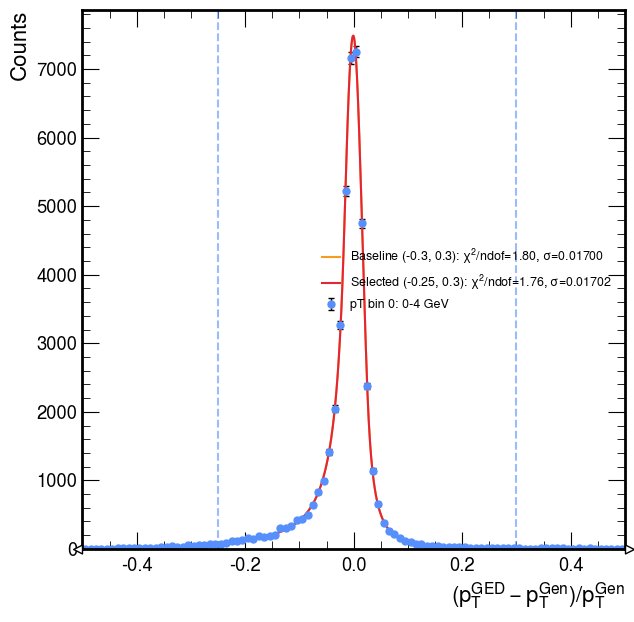

/uscms/home/reshmar/nobackup/miniforge3/envs/coffea/lib/python3.8/site-packages/mplhep/plot.py:494: UserWarning: marker is redundantly defined by the 'marker' keyword argument and the fmt string "o" (-> marker='o'). The keyword argument will take precedence.
  _e = ax.errorbar(


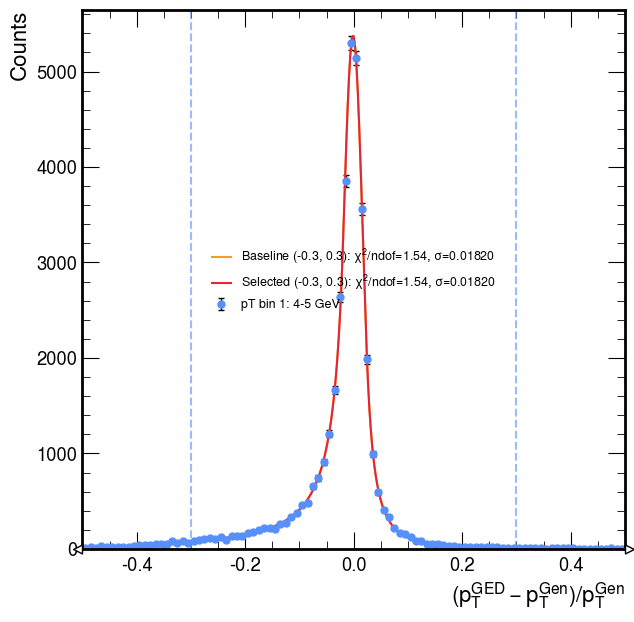

/uscms/home/reshmar/nobackup/miniforge3/envs/coffea/lib/python3.8/site-packages/mplhep/plot.py:494: UserWarning: marker is redundantly defined by the 'marker' keyword argument and the fmt string "o" (-> marker='o'). The keyword argument will take precedence.
  _e = ax.errorbar(


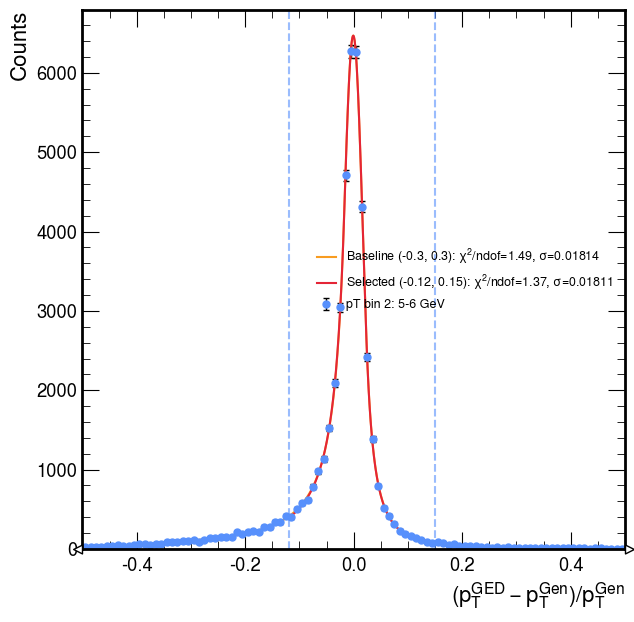

/uscms/home/reshmar/nobackup/miniforge3/envs/coffea/lib/python3.8/site-packages/mplhep/plot.py:494: UserWarning: marker is redundantly defined by the 'marker' keyword argument and the fmt string "o" (-> marker='o'). The keyword argument will take precedence.
  _e = ax.errorbar(


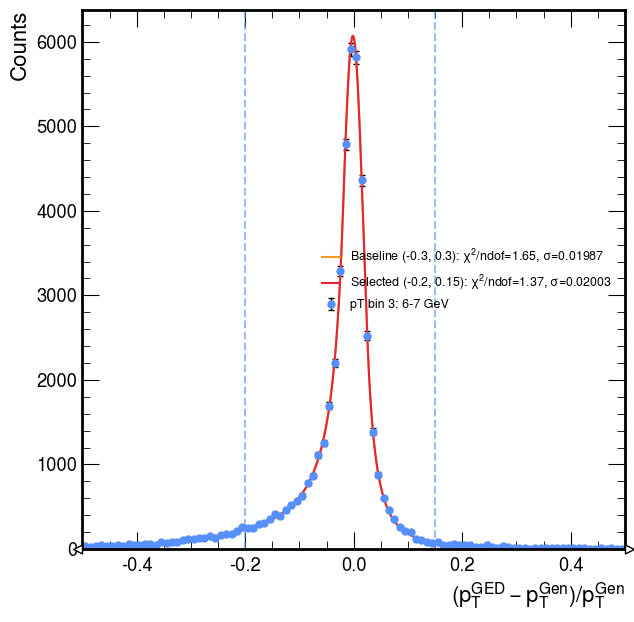

/uscms/home/reshmar/nobackup/miniforge3/envs/coffea/lib/python3.8/site-packages/mplhep/plot.py:494: UserWarning: marker is redundantly defined by the 'marker' keyword argument and the fmt string "o" (-> marker='o'). The keyword argument will take precedence.
  _e = ax.errorbar(


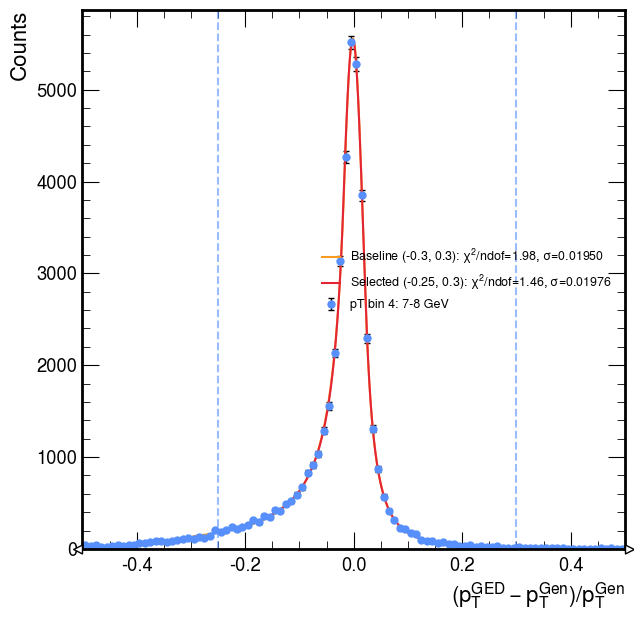

/uscms/home/reshmar/nobackup/miniforge3/envs/coffea/lib/python3.8/site-packages/mplhep/plot.py:494: UserWarning: marker is redundantly defined by the 'marker' keyword argument and the fmt string "o" (-> marker='o'). The keyword argument will take precedence.
  _e = ax.errorbar(


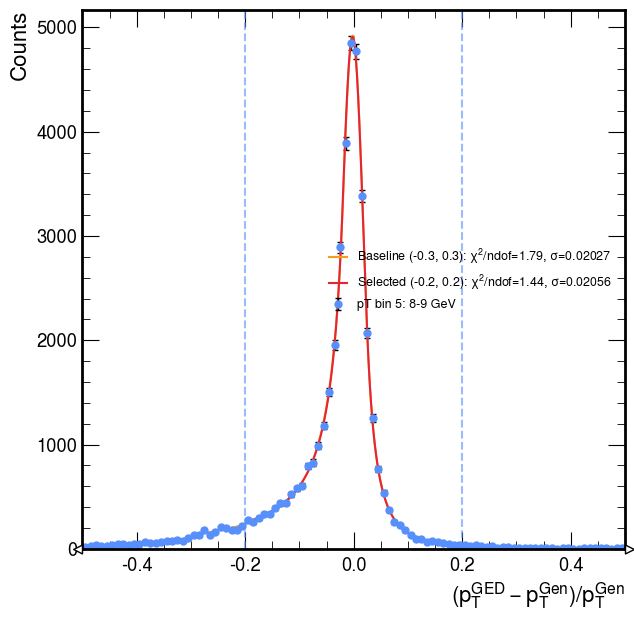

/uscms/home/reshmar/nobackup/miniforge3/envs/coffea/lib/python3.8/site-packages/mplhep/plot.py:494: UserWarning: marker is redundantly defined by the 'marker' keyword argument and the fmt string "o" (-> marker='o'). The keyword argument will take precedence.
  _e = ax.errorbar(


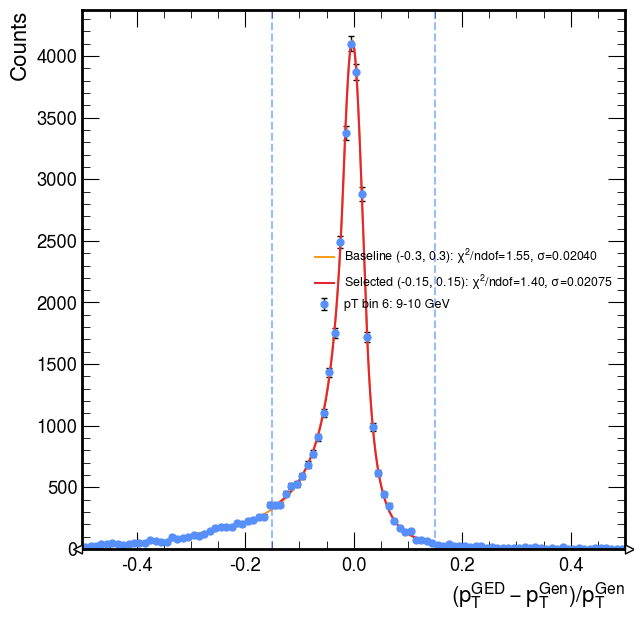

/uscms/home/reshmar/nobackup/miniforge3/envs/coffea/lib/python3.8/site-packages/mplhep/plot.py:494: UserWarning: marker is redundantly defined by the 'marker' keyword argument and the fmt string "o" (-> marker='o'). The keyword argument will take precedence.
  _e = ax.errorbar(


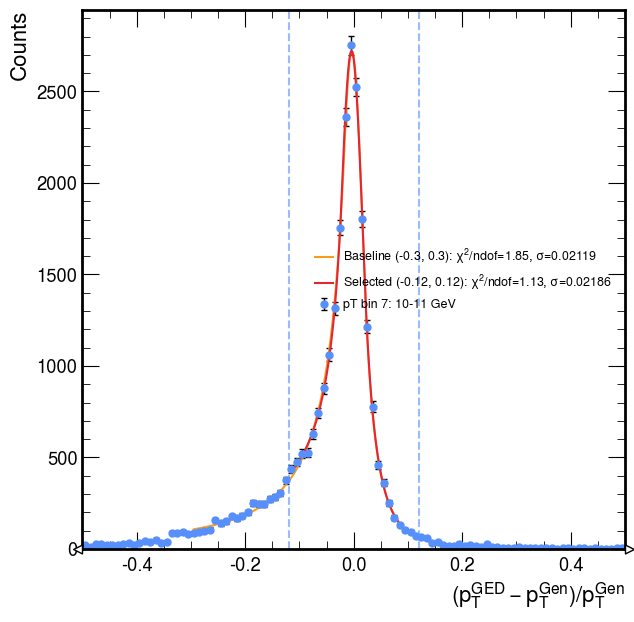

/uscms/home/reshmar/nobackup/miniforge3/envs/coffea/lib/python3.8/site-packages/mplhep/plot.py:494: UserWarning: marker is redundantly defined by the 'marker' keyword argument and the fmt string "o" (-> marker='o'). The keyword argument will take precedence.
  _e = ax.errorbar(


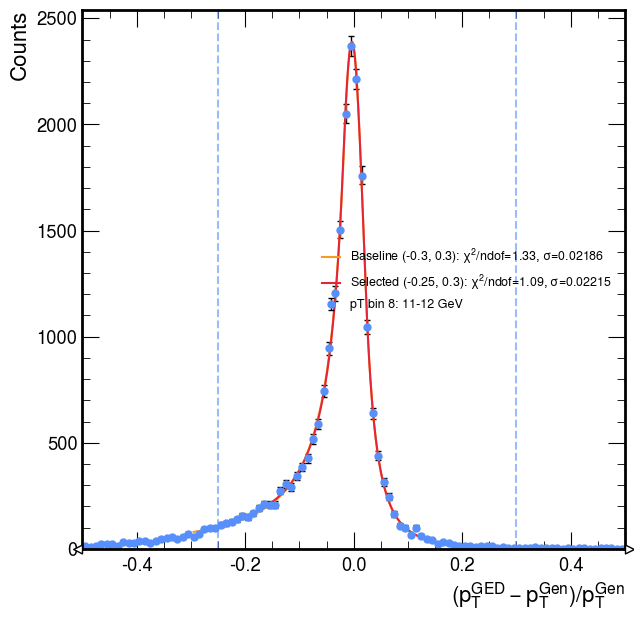

/uscms/home/reshmar/nobackup/miniforge3/envs/coffea/lib/python3.8/site-packages/mplhep/plot.py:494: UserWarning: marker is redundantly defined by the 'marker' keyword argument and the fmt string "o" (-> marker='o'). The keyword argument will take precedence.
  _e = ax.errorbar(


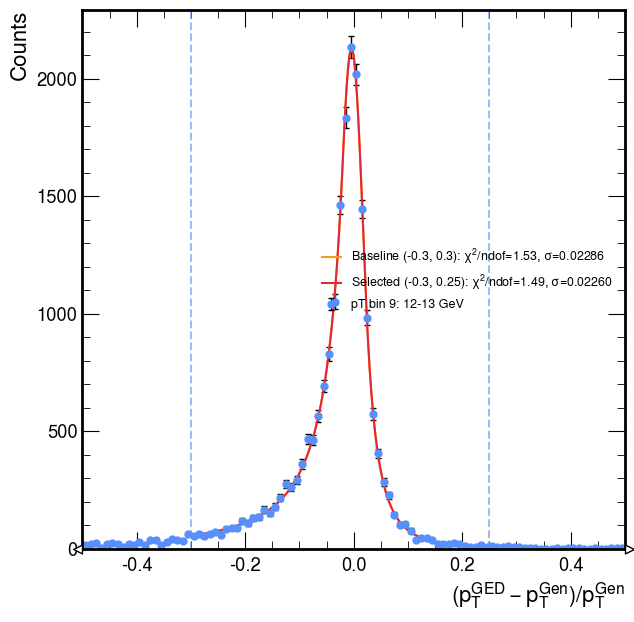

/uscms/home/reshmar/nobackup/miniforge3/envs/coffea/lib/python3.8/site-packages/mplhep/plot.py:494: UserWarning: marker is redundantly defined by the 'marker' keyword argument and the fmt string "o" (-> marker='o'). The keyword argument will take precedence.
  _e = ax.errorbar(


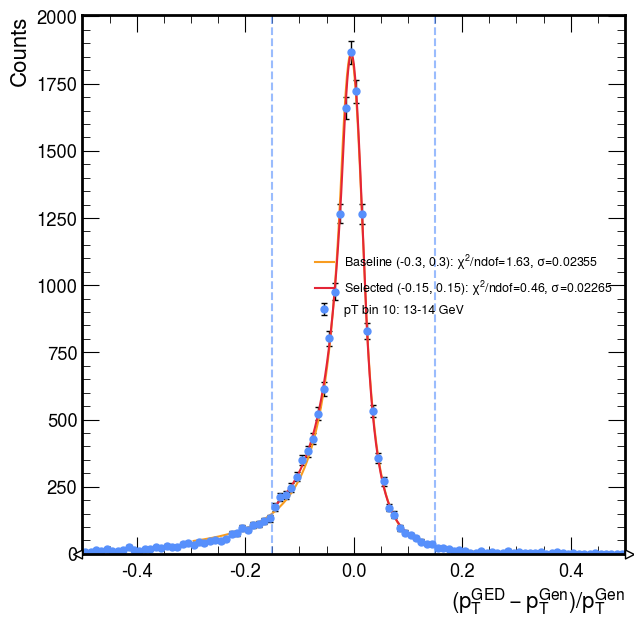

/uscms/home/reshmar/nobackup/miniforge3/envs/coffea/lib/python3.8/site-packages/mplhep/plot.py:494: UserWarning: marker is redundantly defined by the 'marker' keyword argument and the fmt string "o" (-> marker='o'). The keyword argument will take precedence.
  _e = ax.errorbar(


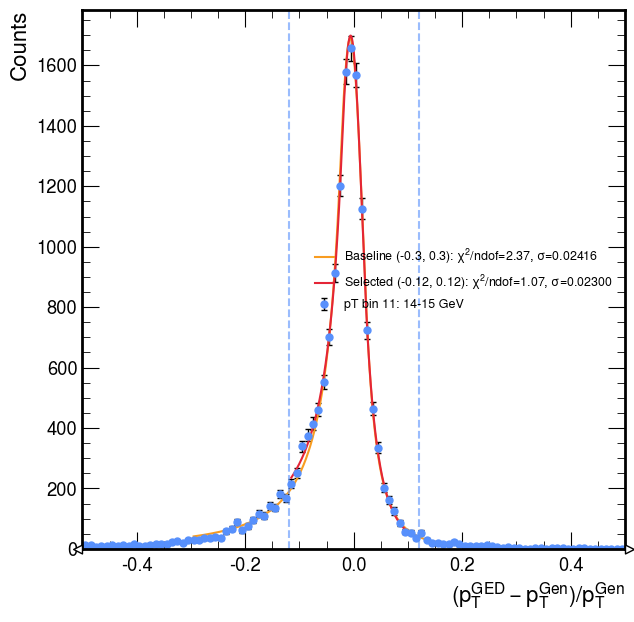

/uscms/home/reshmar/nobackup/miniforge3/envs/coffea/lib/python3.8/site-packages/mplhep/plot.py:494: UserWarning: marker is redundantly defined by the 'marker' keyword argument and the fmt string "o" (-> marker='o'). The keyword argument will take precedence.
  _e = ax.errorbar(


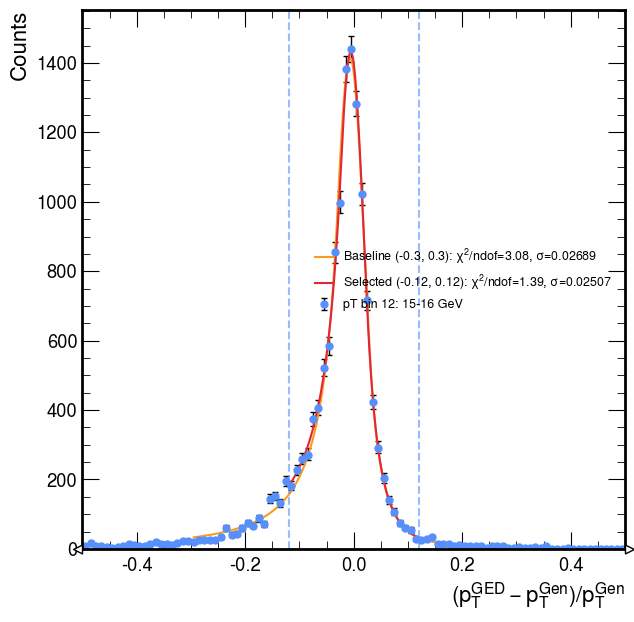

/uscms/home/reshmar/nobackup/miniforge3/envs/coffea/lib/python3.8/site-packages/mplhep/plot.py:494: UserWarning: marker is redundantly defined by the 'marker' keyword argument and the fmt string "o" (-> marker='o'). The keyword argument will take precedence.
  _e = ax.errorbar(


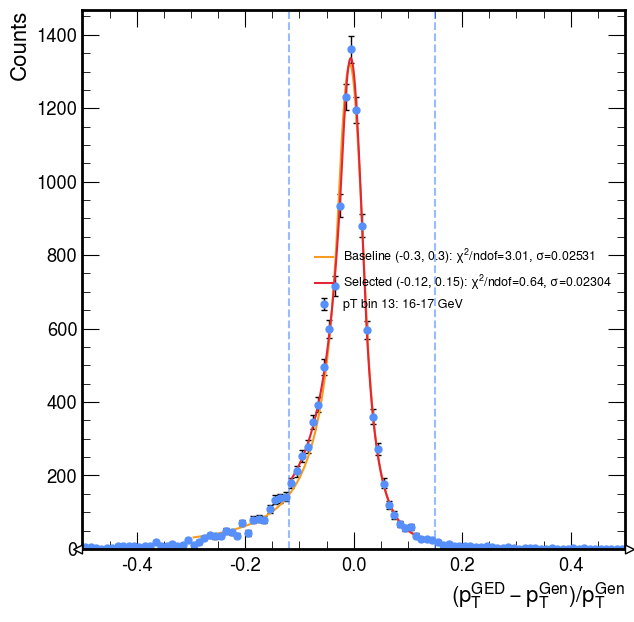

/uscms/home/reshmar/nobackup/miniforge3/envs/coffea/lib/python3.8/site-packages/mplhep/plot.py:494: UserWarning: marker is redundantly defined by the 'marker' keyword argument and the fmt string "o" (-> marker='o'). The keyword argument will take precedence.
  _e = ax.errorbar(


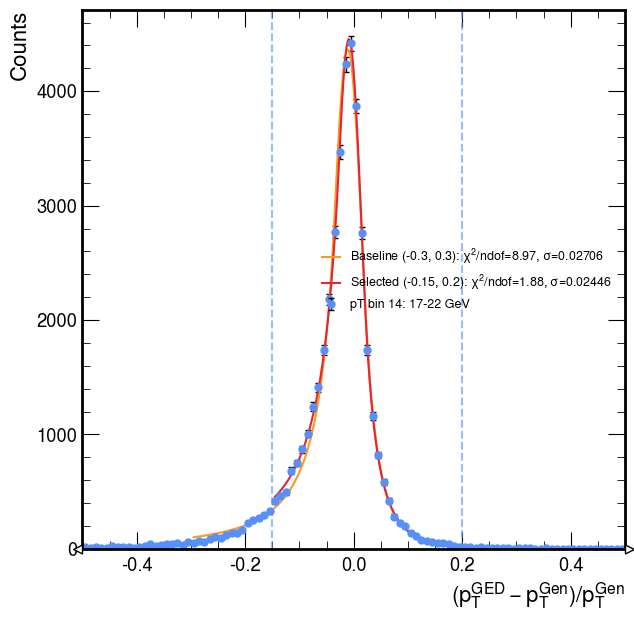

/uscms/home/reshmar/nobackup/miniforge3/envs/coffea/lib/python3.8/site-packages/mplhep/plot.py:494: UserWarning: marker is redundantly defined by the 'marker' keyword argument and the fmt string "o" (-> marker='o'). The keyword argument will take precedence.
  _e = ax.errorbar(


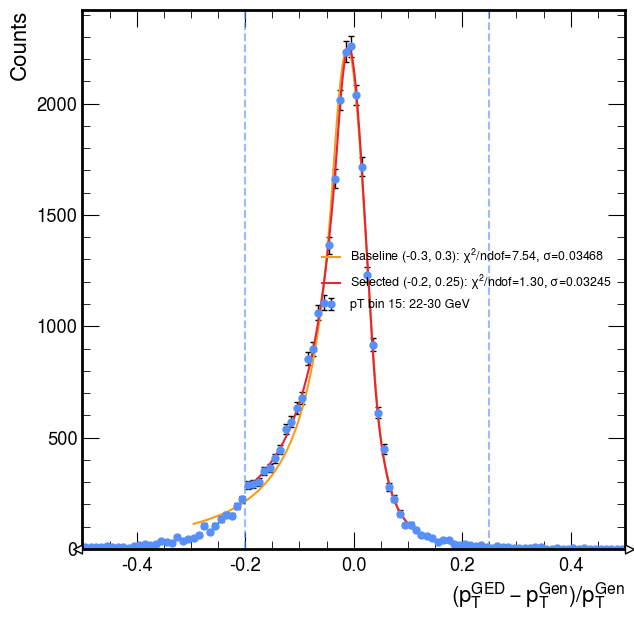

In [28]:
for idx in range(n_pt_bins):
    baseline = baseline_results[idx]
    selected_range = selected_fit_ranges[idx]
    selected = range_scan_fits[idx].get(selected_range, baseline)

    plt.figure(figsize=(7, 7))
    mplhep.histplot(
        h_fit[idx, :],
        histtype='errorbar',
        yerr=True,
        fmt='o',
        capsize=2,
        ecolor='black',
        label=f'pT bin {idx}: {baseline["genpt_bin"][0]:g}-{baseline["genpt_bin"][1]:g} GeV'
    )

    x_base = np.linspace(baseline['xfit'].min(), baseline['xfit'].max(), 500)
    plt.plot(
        x_base,
        double_cb(x_base, *baseline['popt']),
        label=(f'Baseline {ORIGINAL_FIT_RANGE}: '
               f'$\\chi^2$/ndof={baseline["chi2/ndof"]:.2f}, '
               f'$\\sigma$={baseline["fit_sigma"]:.5f}')
    )

    x_sel = np.linspace(selected['xfit'].min(), selected['xfit'].max(), 500)
    plt.plot(
        x_sel,
        double_cb(x_sel, *selected['popt']),
        label=(f'Selected {selected_range}: '
               f'$\\chi^2$/ndof={selected["chi2/ndof"]:.2f}, '
               f'$\\sigma$={selected["fit_sigma"]:.5f}')
    )

    # Visually mark the selected fit interval.
    plt.axvline(selected_range[0], linestyle='--', alpha=0.6)
    plt.axvline(selected_range[1], linestyle='--', alpha=0.6)

    plt.xlim(plot_min, plot_max)
    plt.xlabel(r'$(p_T^{GED}-p_T^{Gen})/p_T^{Gen}$')
    plt.ylabel('Counts')
    plt.legend(fontsize=9)
    plt.show()

## 4. Optional manual overrides

The automatic selection is deliberately conservative, but the overlay plots should still be inspected. If you prefer a specific range for a bin after looking at the physics shape, put it in `MANUAL_RANGE_OVERRIDE` in the settings cell and rerun from there.

The final range dictionary below applies those overrides **without changing any other fit setting**.

In [29]:
final_fit_ranges = selected_fit_ranges.copy()

for idx, fit_range in MANUAL_RANGE_OVERRIDE.items():
    if idx < 0 or idx >= n_pt_bins:
        raise IndexError(f'Manual override pT-bin index {idx} is outside 0..{n_pt_bins-1}.')
    final_fit_ranges[idx] = tuple(fit_range)

print('Final fit ranges:')
for idx in range(n_pt_bins):
    auto_tag = 'manual override' if idx in MANUAL_RANGE_OVERRIDE else 'automatic'
    print(f'  bin {idx:2d}  pT={baseline_results[idx]["genpt_bin"]}  '
          f'range={final_fit_ranges[idx]}  [{auto_tag}]')

Final fit ranges:
  bin  0  pT=(0.0, 4.0)  range=(-0.25, 0.3)  [automatic]
  bin  1  pT=(4.0, 5.0)  range=(-0.3, 0.3)  [automatic]
  bin  2  pT=(5.0, 6.0)  range=(-0.12, 0.15)  [automatic]
  bin  3  pT=(6.0, 7.0)  range=(-0.2, 0.15)  [automatic]
  bin  4  pT=(7.0, 8.0)  range=(-0.25, 0.3)  [automatic]
  bin  5  pT=(8.0, 9.0)  range=(-0.2, 0.2)  [automatic]
  bin  6  pT=(9.0, 10.0)  range=(-0.15, 0.15)  [automatic]
  bin  7  pT=(10.0, 11.0)  range=(-0.12, 0.12)  [automatic]
  bin  8  pT=(11.0, 12.0)  range=(-0.25, 0.3)  [automatic]
  bin  9  pT=(12.0, 13.0)  range=(-0.3, 0.25)  [automatic]
  bin 10  pT=(13.0, 14.0)  range=(-0.15, 0.15)  [automatic]
  bin 11  pT=(14.0, 15.0)  range=(-0.12, 0.12)  [automatic]
  bin 12  pT=(15.0, 16.0)  range=(-0.12, 0.12)  [automatic]
  bin 13  pT=(16.0, 17.0)  range=(-0.12, 0.15)  [automatic]
  bin 14  pT=(17.0, 22.0)  range=(-0.15, 0.2)  [automatic]
  bin 15  pT=(22.0, 30.0)  range=(-0.2, 0.25)  [automatic]


## 5. Final per-bin fits and compact comparison table

This is the fit collection to use downstream. The output retains the same quantities as your original `fit_data`, with the selected range and the baseline comparison added.

In [30]:
fit_data = []
final_fit_results = {}
comparison_rows = []

for idx in range(n_pt_bins):
    final_range = final_fit_ranges[idx]

    # Reuse an already-scanned fit when possible; otherwise evaluate a manual range now.
    if final_range in range_scan_fits[idx]:
        result = range_scan_fits[idx][final_range]
    else:
        result = fit_one_bin(idx, final_range)

    baseline = baseline_results[idx]
    final_fit_results[idx] = result

    sigma_rel_change = abs(result['fit_sigma'] - baseline['fit_sigma']) / baseline['fit_sigma']

    fit_data.append({
        'pT bin index': idx,
        'genptbin_range': result['genpt_bin'],
        'fit_mean': result['fit_mean'],
        'fit_mean_unc': result['fit_mean_unc'],
        'fit_sigma': result['fit_sigma'],
        'fit_sigma_unc': result['fit_sigma_unc'],
        'chi2/ndof': result['chi2/ndof'],
        'fit_range': result['fit_range'],
    })

    comparison_rows.append({
        'pT bin index': idx,
        'gen pT range': result['genpt_bin'],
        'final range': result['fit_range'],
        'baseline chi2/ndof': baseline['chi2/ndof'],
        'final chi2/ndof': result['chi2/ndof'],
        'baseline sigma': baseline['fit_sigma'],
        'final sigma': result['fit_sigma'],
        'sigma rel. change': sigma_rel_change,
        'sigma stable': sigma_rel_change <= MAX_SIGMA_REL_CHANGE,
    })

comparison_df = pd.DataFrame(comparison_rows)
fit_df = pd.DataFrame(fit_data)

display(comparison_df)

# Make any sigma-protection violation very obvious.
violations = comparison_df[~comparison_df['sigma stable']]
if len(violations) > 0:
    print('WARNING: final manual choices contain sigma-stability violations:')
    display(violations)
else:
    print('All final fits satisfy the sigma-stability requirement.')

,pT bin index,gen pT range,final range,baseline chi2/ndof,final chi2/ndof,baseline sigma,final sigma,sigma rel. change,sigma stable
0,0,"(0.0, 4.0)","(-0.25, 0.3)",1.798380,1.760133,0.016996,0.017020,0.001395,True
1,1,"(4.0, 5.0)","(-0.3, 0.3)",1.542001,1.542001,0.018198,0.018198,0.000000,True
2,2,"(5.0, 6.0)","(-0.12, 0.15)",1.492207,1.368778,0.018138,0.018113,0.001361,True
3,3,"(6.0, 7.0)","(-0.2, 0.15)",1.649210,1.370290,0.019873,0.020031,0.007973,True
4,4,"(7.0, 8.0)","(-0.25, 0.3)",1.979081,1.457225,0.019495,0.019762,0.013686,True
5,5,"(8.0, 9.0)","(-0.2, 0.2)",1.786683,1.439112,0.020271,0.020562,0.014360,True
6,6,"(9.0, 10.0)","(-0.15, 0.15)",1.547545,1.404408,0.020405,0.020753,0.017037,True
7,7,"(10.0, 11.0)","(-0.12, 0.12)",1.847017,1.127542,0.021188,0.021860,0.031744,True
8,8,"(11.0, 12.0)","(-0.25, 0.3)",1.327240,1.094048,0.021859,0.022146,0.013119,True
9,9,"(12.0, 13.0)","(-0.3, 0.25)",1.532693,1.492333,0.022855,0.022597,0.011299,True


All final fits satisfy the sigma-stability requirement.


/uscms/home/reshmar/nobackup/miniforge3/envs/coffea/lib/python3.8/site-packages/mplhep/plot.py:494: UserWarning: marker is redundantly defined by the 'marker' keyword argument and the fmt string "o" (-> marker='o'). The keyword argument will take precedence.
  _e = ax.errorbar(


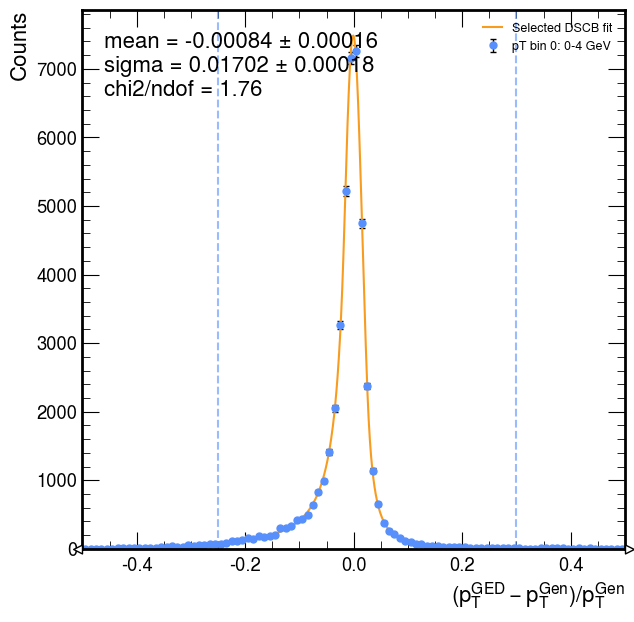

/uscms/home/reshmar/nobackup/miniforge3/envs/coffea/lib/python3.8/site-packages/mplhep/plot.py:494: UserWarning: marker is redundantly defined by the 'marker' keyword argument and the fmt string "o" (-> marker='o'). The keyword argument will take precedence.
  _e = ax.errorbar(


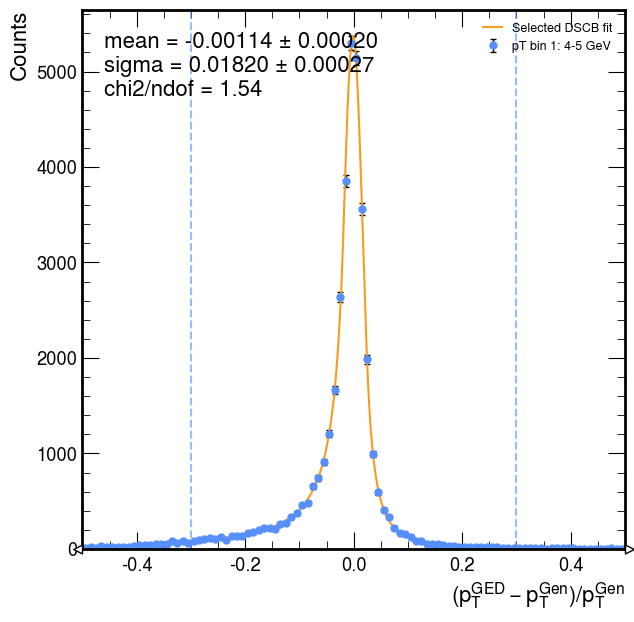

/uscms/home/reshmar/nobackup/miniforge3/envs/coffea/lib/python3.8/site-packages/mplhep/plot.py:494: UserWarning: marker is redundantly defined by the 'marker' keyword argument and the fmt string "o" (-> marker='o'). The keyword argument will take precedence.
  _e = ax.errorbar(


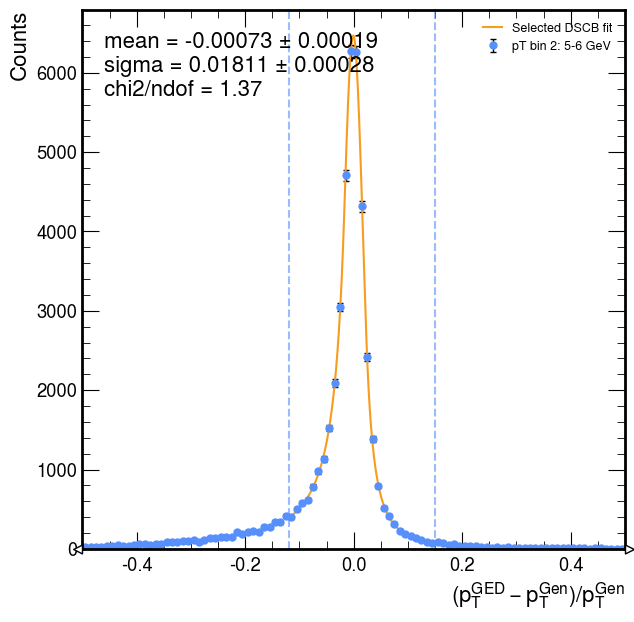

/uscms/home/reshmar/nobackup/miniforge3/envs/coffea/lib/python3.8/site-packages/mplhep/plot.py:494: UserWarning: marker is redundantly defined by the 'marker' keyword argument and the fmt string "o" (-> marker='o'). The keyword argument will take precedence.
  _e = ax.errorbar(


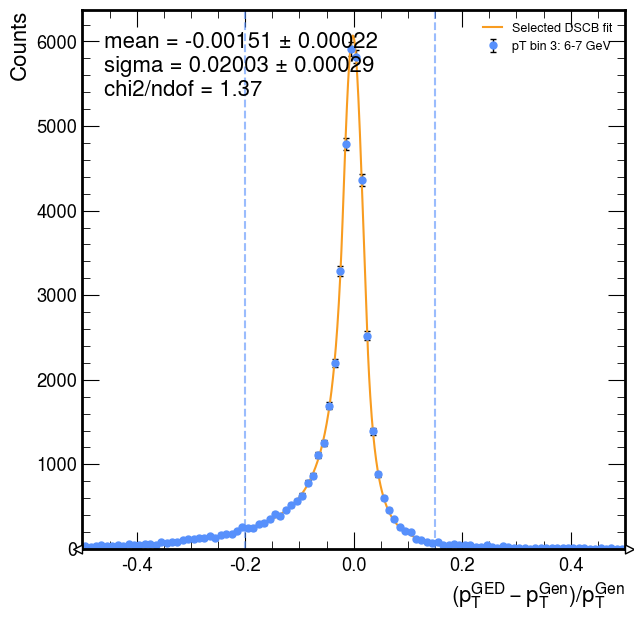

/uscms/home/reshmar/nobackup/miniforge3/envs/coffea/lib/python3.8/site-packages/mplhep/plot.py:494: UserWarning: marker is redundantly defined by the 'marker' keyword argument and the fmt string "o" (-> marker='o'). The keyword argument will take precedence.
  _e = ax.errorbar(


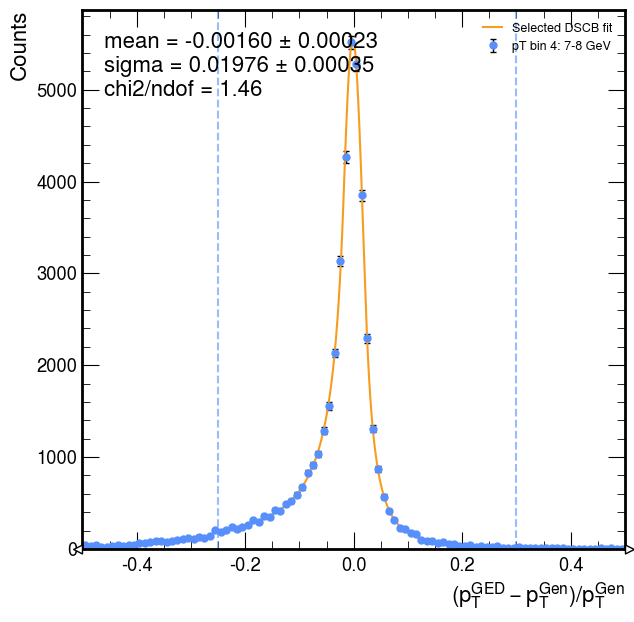

/uscms/home/reshmar/nobackup/miniforge3/envs/coffea/lib/python3.8/site-packages/mplhep/plot.py:494: UserWarning: marker is redundantly defined by the 'marker' keyword argument and the fmt string "o" (-> marker='o'). The keyword argument will take precedence.
  _e = ax.errorbar(


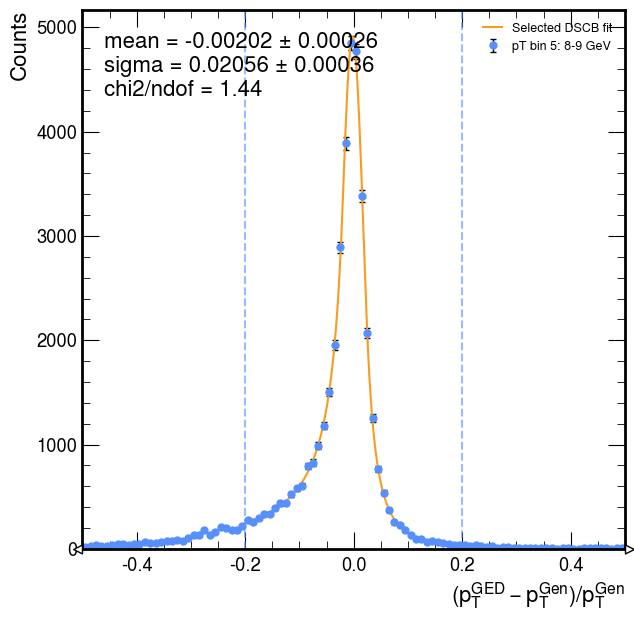

/uscms/home/reshmar/nobackup/miniforge3/envs/coffea/lib/python3.8/site-packages/mplhep/plot.py:494: UserWarning: marker is redundantly defined by the 'marker' keyword argument and the fmt string "o" (-> marker='o'). The keyword argument will take precedence.
  _e = ax.errorbar(


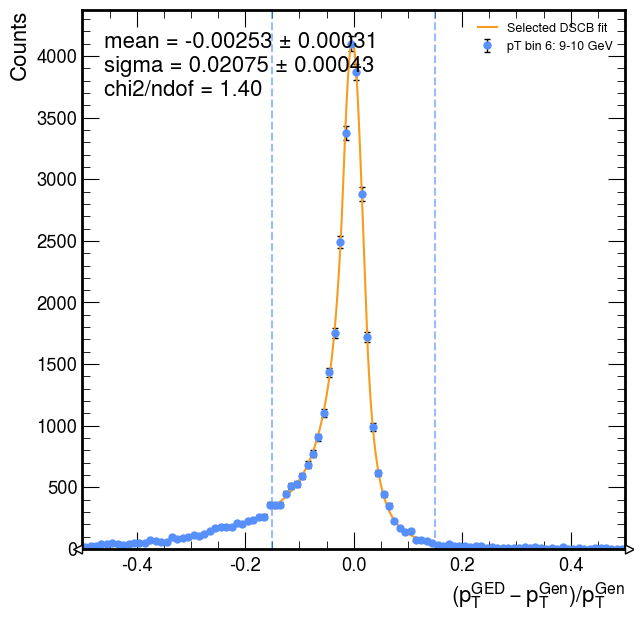

/uscms/home/reshmar/nobackup/miniforge3/envs/coffea/lib/python3.8/site-packages/mplhep/plot.py:494: UserWarning: marker is redundantly defined by the 'marker' keyword argument and the fmt string "o" (-> marker='o'). The keyword argument will take precedence.
  _e = ax.errorbar(


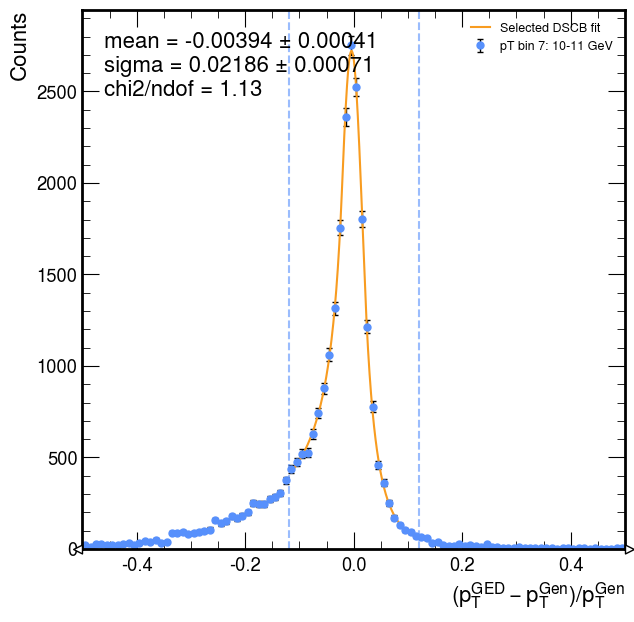

/uscms/home/reshmar/nobackup/miniforge3/envs/coffea/lib/python3.8/site-packages/mplhep/plot.py:494: UserWarning: marker is redundantly defined by the 'marker' keyword argument and the fmt string "o" (-> marker='o'). The keyword argument will take precedence.
  _e = ax.errorbar(


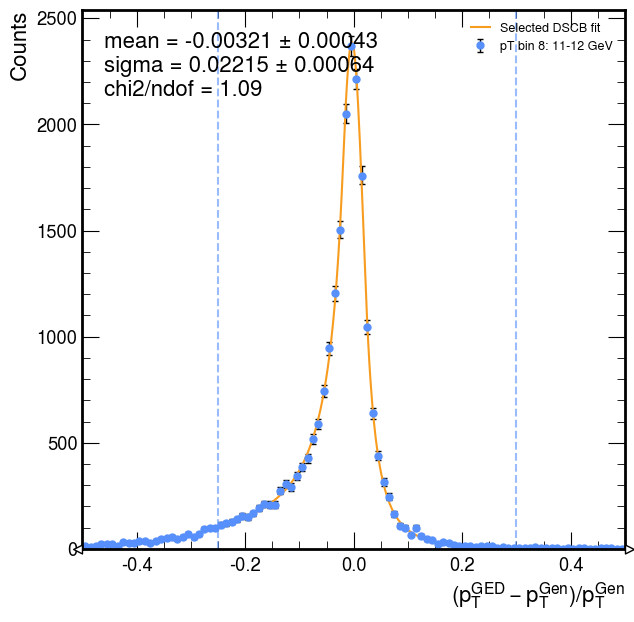

/uscms/home/reshmar/nobackup/miniforge3/envs/coffea/lib/python3.8/site-packages/mplhep/plot.py:494: UserWarning: marker is redundantly defined by the 'marker' keyword argument and the fmt string "o" (-> marker='o'). The keyword argument will take precedence.
  _e = ax.errorbar(


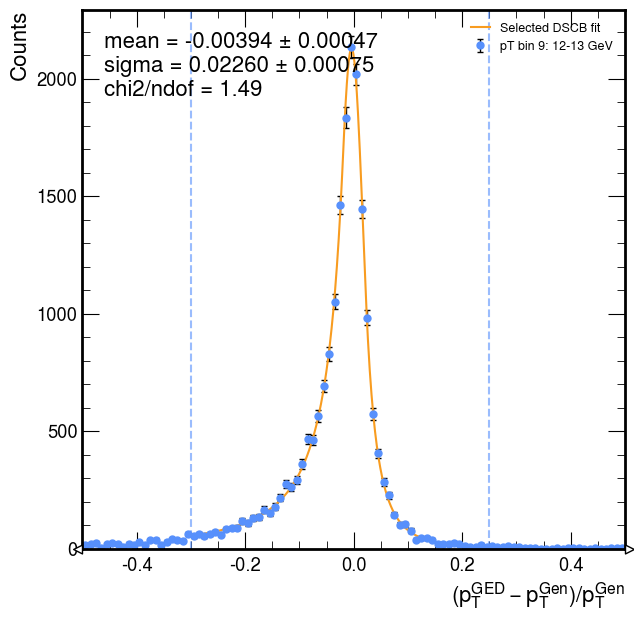

/uscms/home/reshmar/nobackup/miniforge3/envs/coffea/lib/python3.8/site-packages/mplhep/plot.py:494: UserWarning: marker is redundantly defined by the 'marker' keyword argument and the fmt string "o" (-> marker='o'). The keyword argument will take precedence.
  _e = ax.errorbar(


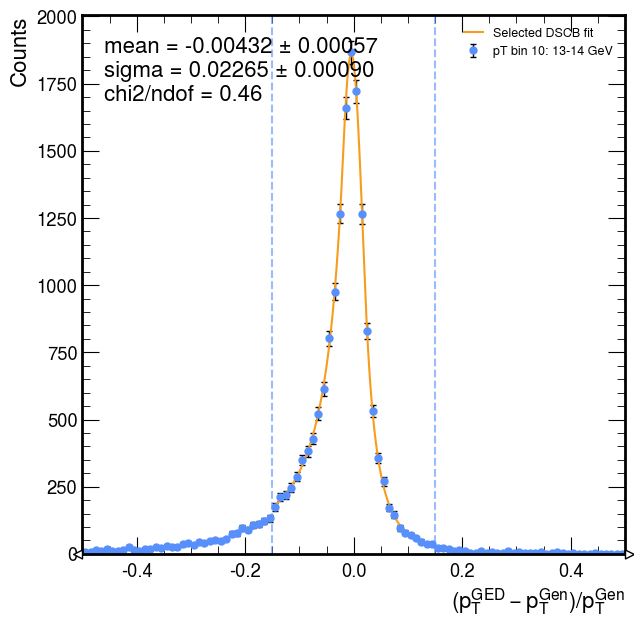

/uscms/home/reshmar/nobackup/miniforge3/envs/coffea/lib/python3.8/site-packages/mplhep/plot.py:494: UserWarning: marker is redundantly defined by the 'marker' keyword argument and the fmt string "o" (-> marker='o'). The keyword argument will take precedence.
  _e = ax.errorbar(


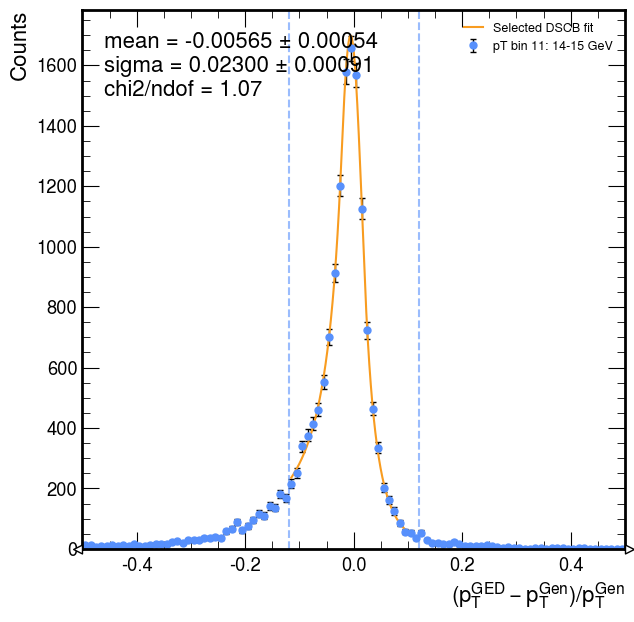

/uscms/home/reshmar/nobackup/miniforge3/envs/coffea/lib/python3.8/site-packages/mplhep/plot.py:494: UserWarning: marker is redundantly defined by the 'marker' keyword argument and the fmt string "o" (-> marker='o'). The keyword argument will take precedence.
  _e = ax.errorbar(


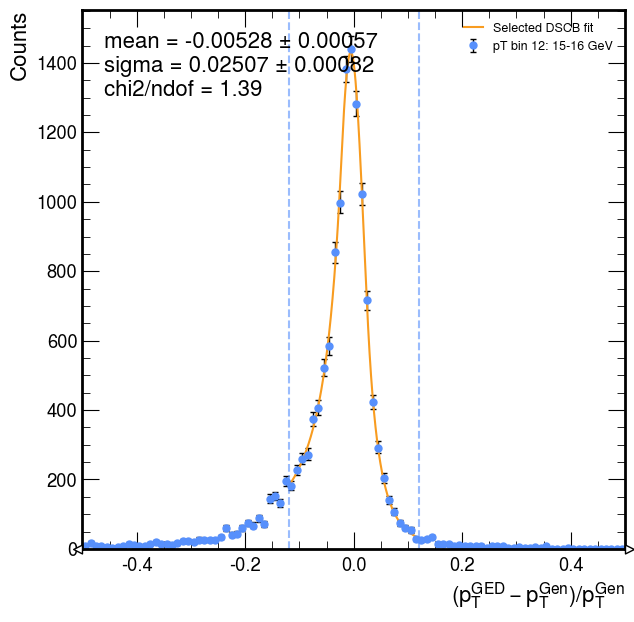

/uscms/home/reshmar/nobackup/miniforge3/envs/coffea/lib/python3.8/site-packages/mplhep/plot.py:494: UserWarning: marker is redundantly defined by the 'marker' keyword argument and the fmt string "o" (-> marker='o'). The keyword argument will take precedence.
  _e = ax.errorbar(


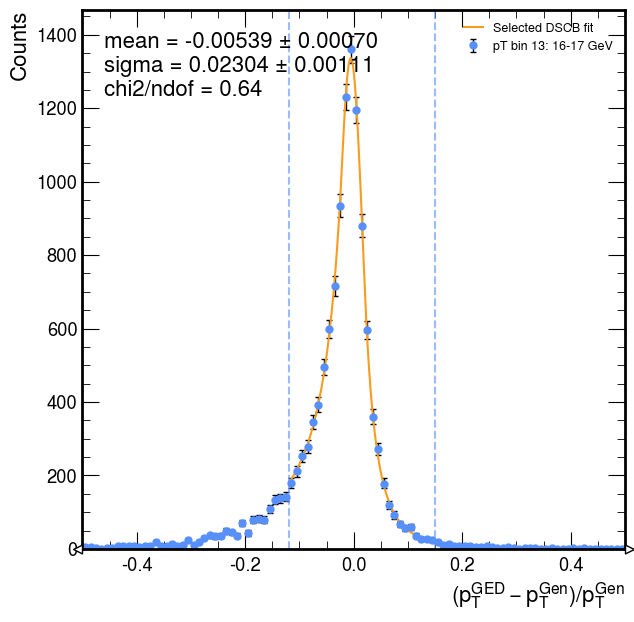

/uscms/home/reshmar/nobackup/miniforge3/envs/coffea/lib/python3.8/site-packages/mplhep/plot.py:494: UserWarning: marker is redundantly defined by the 'marker' keyword argument and the fmt string "o" (-> marker='o'). The keyword argument will take precedence.
  _e = ax.errorbar(


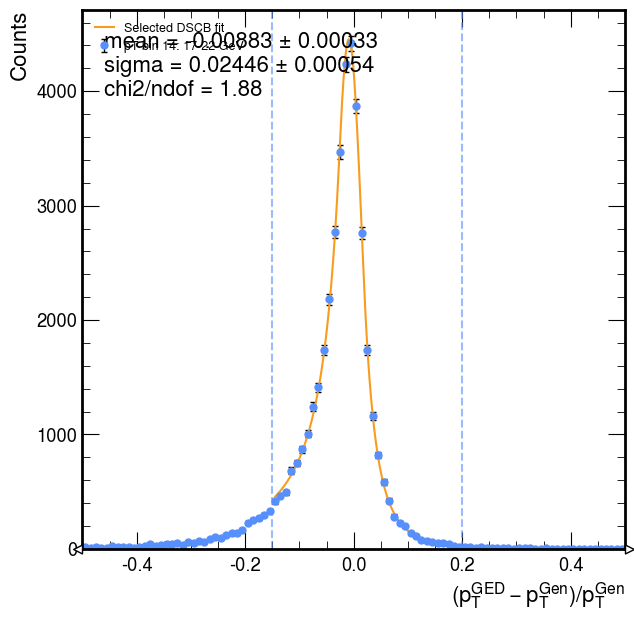

/uscms/home/reshmar/nobackup/miniforge3/envs/coffea/lib/python3.8/site-packages/mplhep/plot.py:494: UserWarning: marker is redundantly defined by the 'marker' keyword argument and the fmt string "o" (-> marker='o'). The keyword argument will take precedence.
  _e = ax.errorbar(


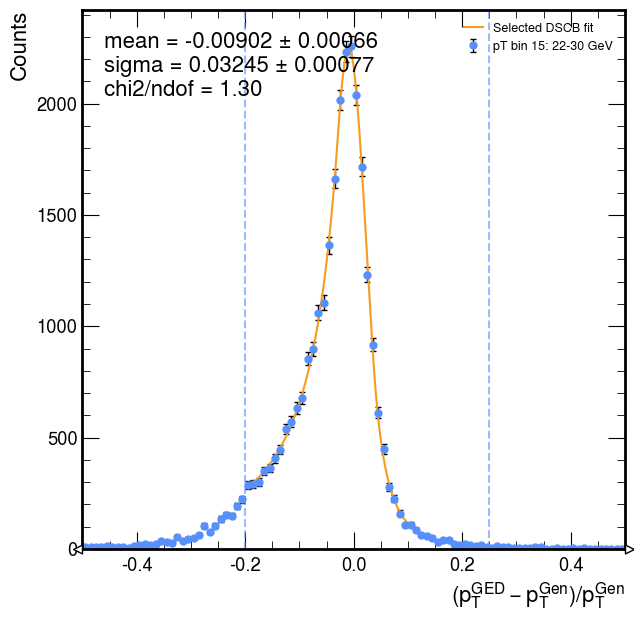

sigma_next= [0.017020173870683917, 0.018198047111280216, 0.01811290602698482, 0.020031129449034762, 0.019762313672699743, 0.020562089203040312, 0.020752557108818917, 0.021860197070917114, 0.022145852264220896, 0.022596775493090505, 0.02264556660405494, 0.023001553037426625, 0.025070577189576625, 0.02303513530476988, 0.024455240324385723, 0.03245412114740538]
sigma_unc_next= [0.00018315550784660223, 0.000273120786409557, 0.0002789991683765307, 0.00028949749656733434, 0.00034657950909942187, 0.00036114106738184624, 0.0004311523270225305, 0.0007054565872678734, 0.0006369129982340319, 0.0007455533806251706, 0.0009041184625913644, 0.0009138954555512769, 0.0008218830099361985, 0.0011062844508471807, 0.0005405149400561178, 0.0007678285752937833]


In [31]:
# ============================================================
# Final fit plots -- one plot per generated-pT bin
# ============================================================
sigma_next=[]
sigma_unc_next = []
for idx in range(n_pt_bins):
    result = final_fit_results[idx]
    baseline = baseline_results[idx]
    sigma_change = abs(result['fit_sigma']-baseline['fit_sigma'])/baseline['fit_sigma']

    plt.figure(figsize=(7, 7))
    mplhep.histplot(
        h_fit[idx, :],
        histtype='errorbar', yerr=True, fmt='o', capsize=2,
        ecolor='black',
        label=f'pT bin {idx}: {result["genpt_bin"][0]:g}-{result["genpt_bin"][1]:g} GeV'
    )

    x_curve = np.linspace(result['xfit'].min(), result['xfit'].max(), 500)
    plt.plot(x_curve, double_cb(x_curve, *result['popt']), label='Selected DSCB fit')

    plt.axvline(result['fit_range'][0], linestyle='--', alpha=0.6)
    plt.axvline(result['fit_range'][1], linestyle='--', alpha=0.6)

    plt.xlim(plot_min, plot_max)
    plt.xlabel(r'$(p_T^{GED}-p_T^{Gen})/p_T^{Gen}$')
    plt.ylabel('Counts')
    plt.text(
        0.04, 0.96,
        (
         f'mean = {result["fit_mean"]:.5f} ± {result["fit_mean_unc"]:.5f}\n'
         f'sigma = {result["fit_sigma"]:.5f} ± {result["fit_sigma_unc"]:.5f}\n'
         
         f'chi2/ndof = {result["chi2/ndof"]:.2f}'),
        transform=plt.gca().transAxes,
        va='top'
    )
    plt.legend(fontsize=9)
    plt.show()
    sigma_next.append(result["fit_sigma"])
    sigma_unc_next.append(result["fit_sigma_unc"])
print ("sigma_next=", sigma_next)
print ("sigma_unc_next=", sigma_unc_next)

## 6. Final pT-resolution summary

This is the same downstream quantity as in your original notebook: the fitted DSCB core `sigma` plotted against the generated-pT bins. The x-axis is correctly labeled as generated pT here.

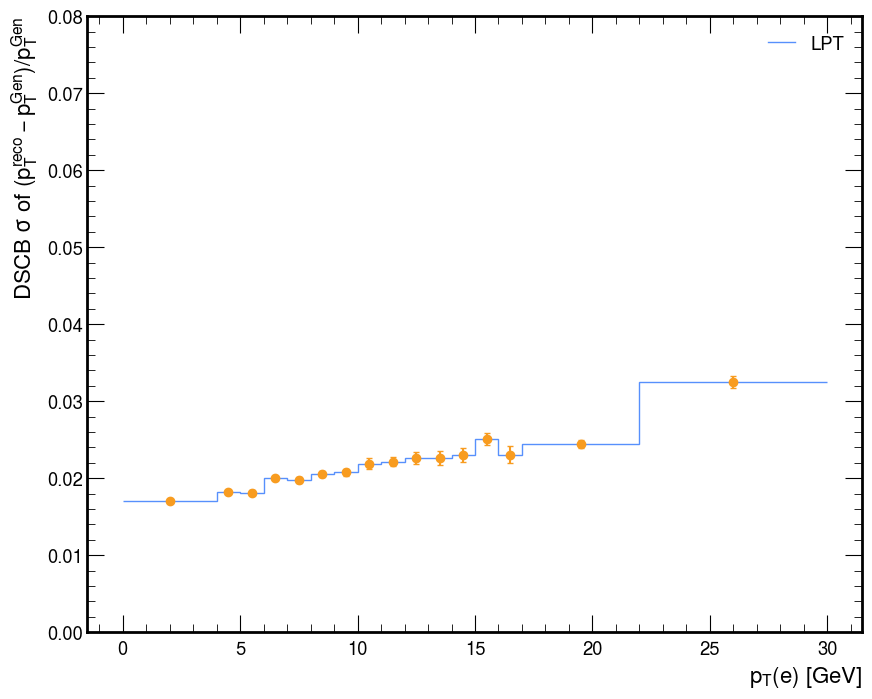

In [32]:
plot_data = []
genpt_edges = []

for item in fit_data:
    pt_low, pt_high = item['genptbin_range']
    pt_center = 0.5 * (pt_low + pt_high)

    if not genpt_edges:
        genpt_edges.append(pt_low)
    genpt_edges.append(pt_high)

    plot_data.append({
        'Genpt_center': pt_center,
        'DSCB sigmafit': item['fit_sigma'],
        'sigma_unc': item['fit_sigma_unc'],
    })

genpt = [p['Genpt_center'] for p in plot_data]
sigma = [p['DSCB sigmafit'] for p in plot_data]
sigma_unc = [p['sigma_unc'] for p in plot_data]

plt.figure(figsize=(10, 8))
plt.stairs(sigma, genpt_edges, baseline=None, label='LPT')
plt.errorbar(genpt, sigma, yerr=sigma_unc, fmt='o', capsize=2)
plt.ylim(0,0.08)
plt.xlabel(r'${p_T}(e)$ [GeV]')
plt.ylabel(r'DSCB $\sigma$ of $(p_T^{reco}-p_T^{Gen})/p_T^{Gen}$')
plt.legend()
plt.show()

### What to inspect after running

The most important outputs are the **selection table** and the **baseline-vs-selected overlay plots**. A lower chi2/ndof is useful only when the central DSCB width remains stable and the selected interval still contains enough of the distribution to constrain the DSCB shape. The final comparison table makes that check explicit for every generated-pT bin.